In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from pathlib import Path
import warnings
import sys
sys.path.append(str(Path.cwd().parent))
from preprocessing_utils import *

In [2]:
plt.style.use(["science", "grid", "notebook"])
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
BASE_DIR = Path.cwd()

data_path = BASE_DIR.parents[5]/"Data"/"bank.csv"

In [4]:
df = pd.read_csv(data_path)

In [5]:
df.head()

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,deposit
0,59,admin.,married,secondary,2343,yes,no,unknown,5,may,1042,1,-1,0,yes
1,56,admin.,married,secondary,45,no,no,unknown,5,may,1467,1,-1,0,yes
2,41,technician,married,secondary,1270,yes,no,unknown,5,may,1389,1,-1,0,yes
3,55,services,married,secondary,2476,yes,no,unknown,5,may,579,1,-1,0,yes
4,54,admin.,married,tertiary,184,no,no,unknown,5,may,673,2,-1,0,yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   balance    11162 non-null  int64 
 5   housing    11162 non-null  object
 6   loan       11162 non-null  object
 7   contact    11162 non-null  object
 8   day        11162 non-null  int64 
 9   month      11162 non-null  object
 10  duration   11162 non-null  int64 
 11  campaign   11162 non-null  int64 
 12  pdays      11162 non-null  int64 
 13  previous   11162 non-null  int64 
 14  deposit    11162 non-null  object
dtypes: int64(7), object(8)
memory usage: 1.3+ MB


In [7]:
df.shape

(11162, 15)

## Check Data Types


In [8]:
check_types(df)

,dtype,num_unique
age,int64,76
job,object,12
marital,object,3
education,object,4
balance,int64,3805
housing,object,2
loan,object,2
contact,object,3
day,int64,31
month,object,12


In [9]:
object_cols = df.select_dtypes("object").columns
df[object_cols] = df[object_cols].astype("category")

check_types(df)


,dtype,num_unique
age,int64,76
job,category,12
marital,category,3
education,category,4
balance,int64,3805
housing,category,2
loan,category,2
contact,category,3
day,int64,31
month,category,12


## Check Null Values


In [10]:
check_null_values(df)

,no_of_nulls
age,0
job,0
marital,0
education,0
balance,0
housing,0
loan,0
contact,0
day,0
month,0


In [11]:
calculate_null_val_percentages(df)

,null_percentage
age,0.0
job,0.0
marital,0.0
education,0.0
balance,0.0
housing,0.0
loan,0.0
contact,0.0
day,0.0
month,0.0


## Statistical Summary


In [12]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [13]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after removing duplicates: (11162, 15)


## Outlier Detection


In [14]:
numerical_cols = df.select_dtypes("number").columns
print(f"Numerical columns: {list(numerical_cols)}")

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


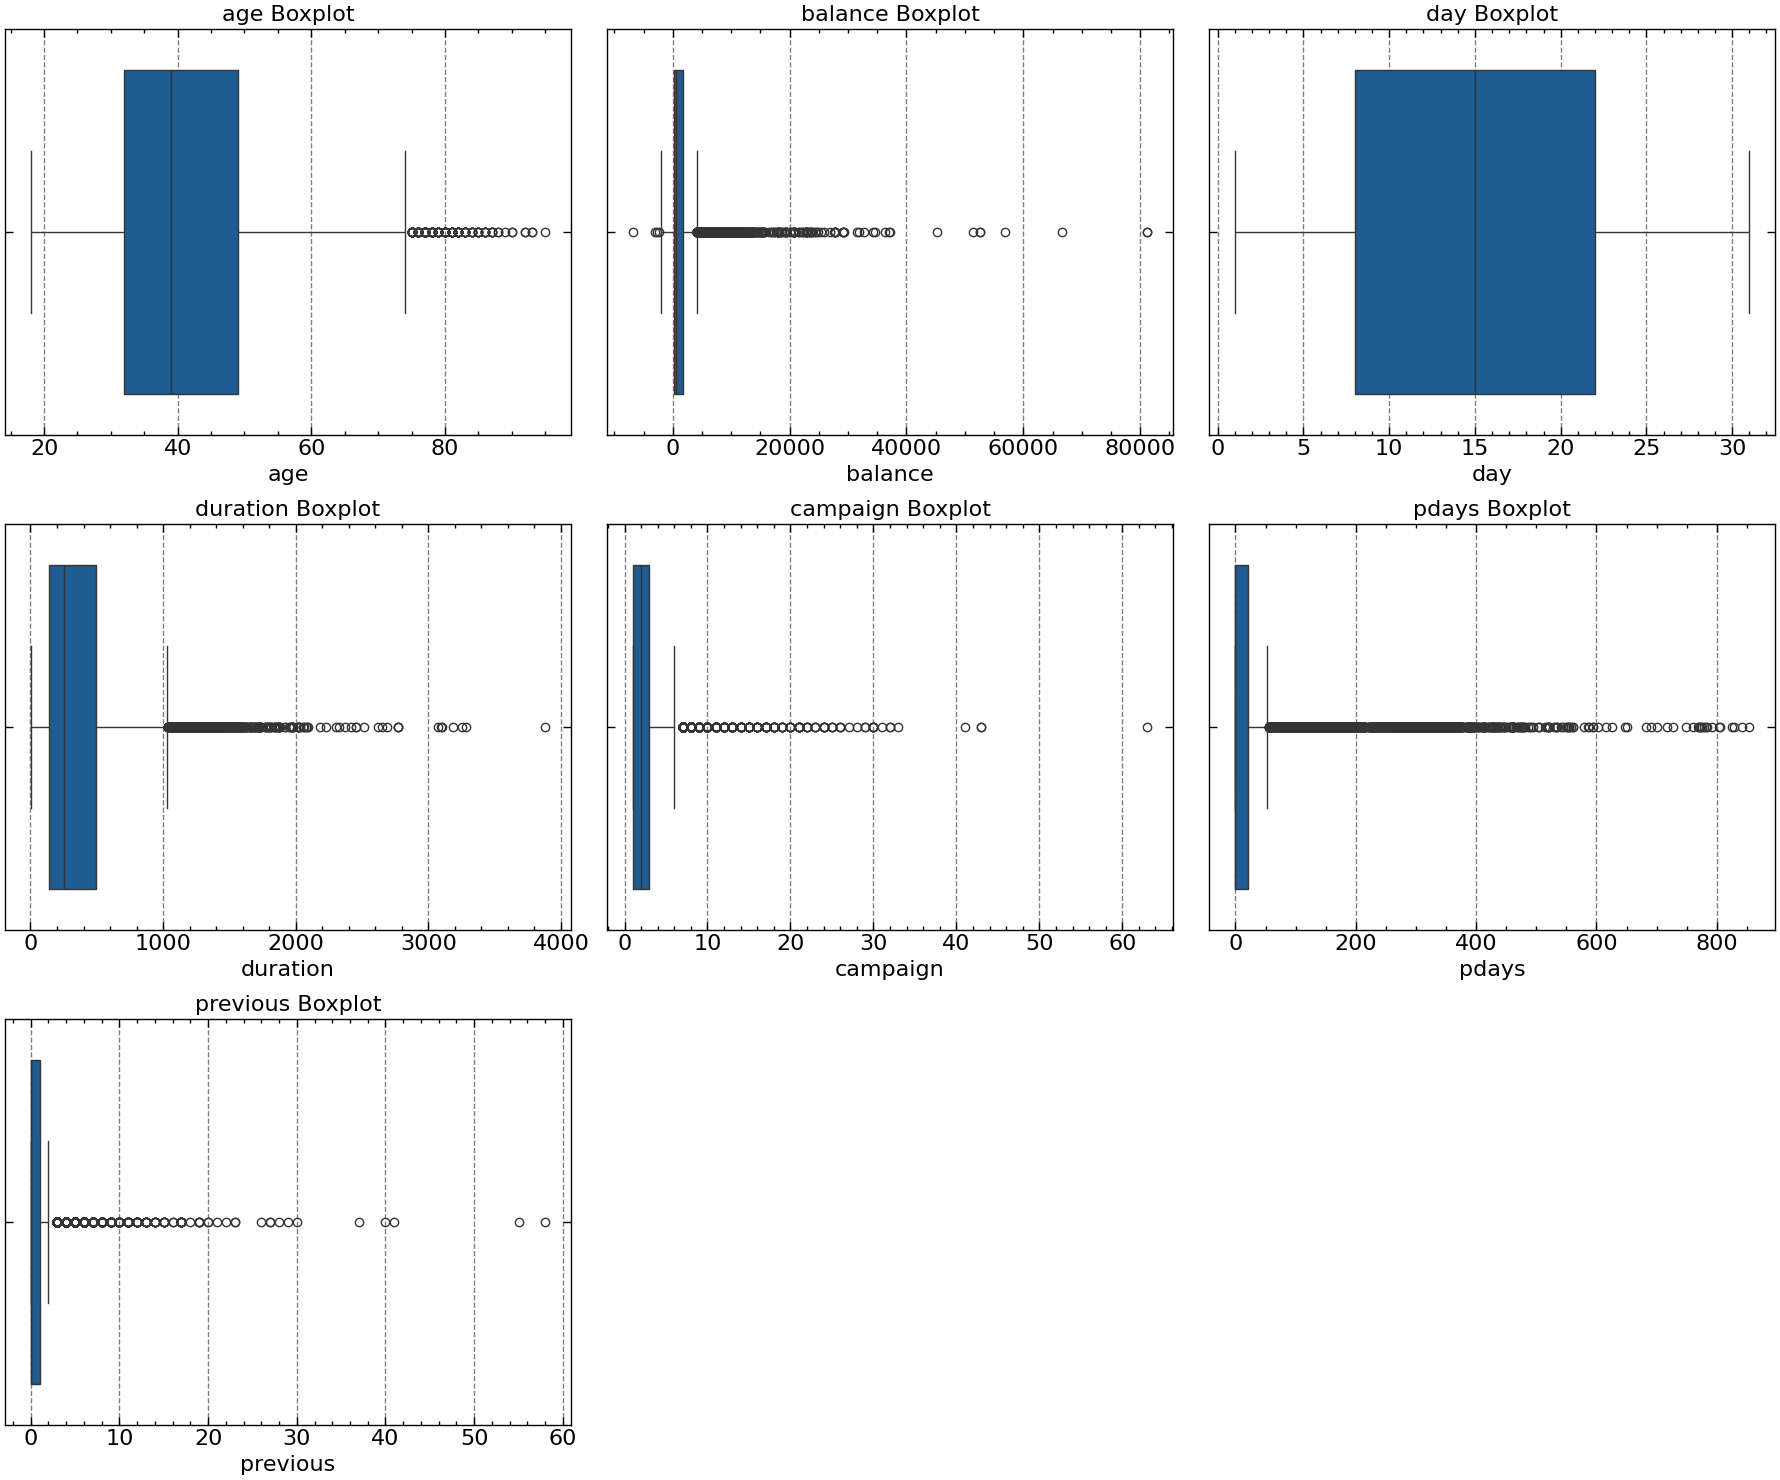

In [15]:
num_cols_list = list(numerical_cols)
num_plots = len(num_cols_list)
rows = (num_plots // 3) + (1 if num_plots % 3 != 0 else 0)

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(num_cols_list):
    plt.subplot(rows, 3, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

## Data Visualization


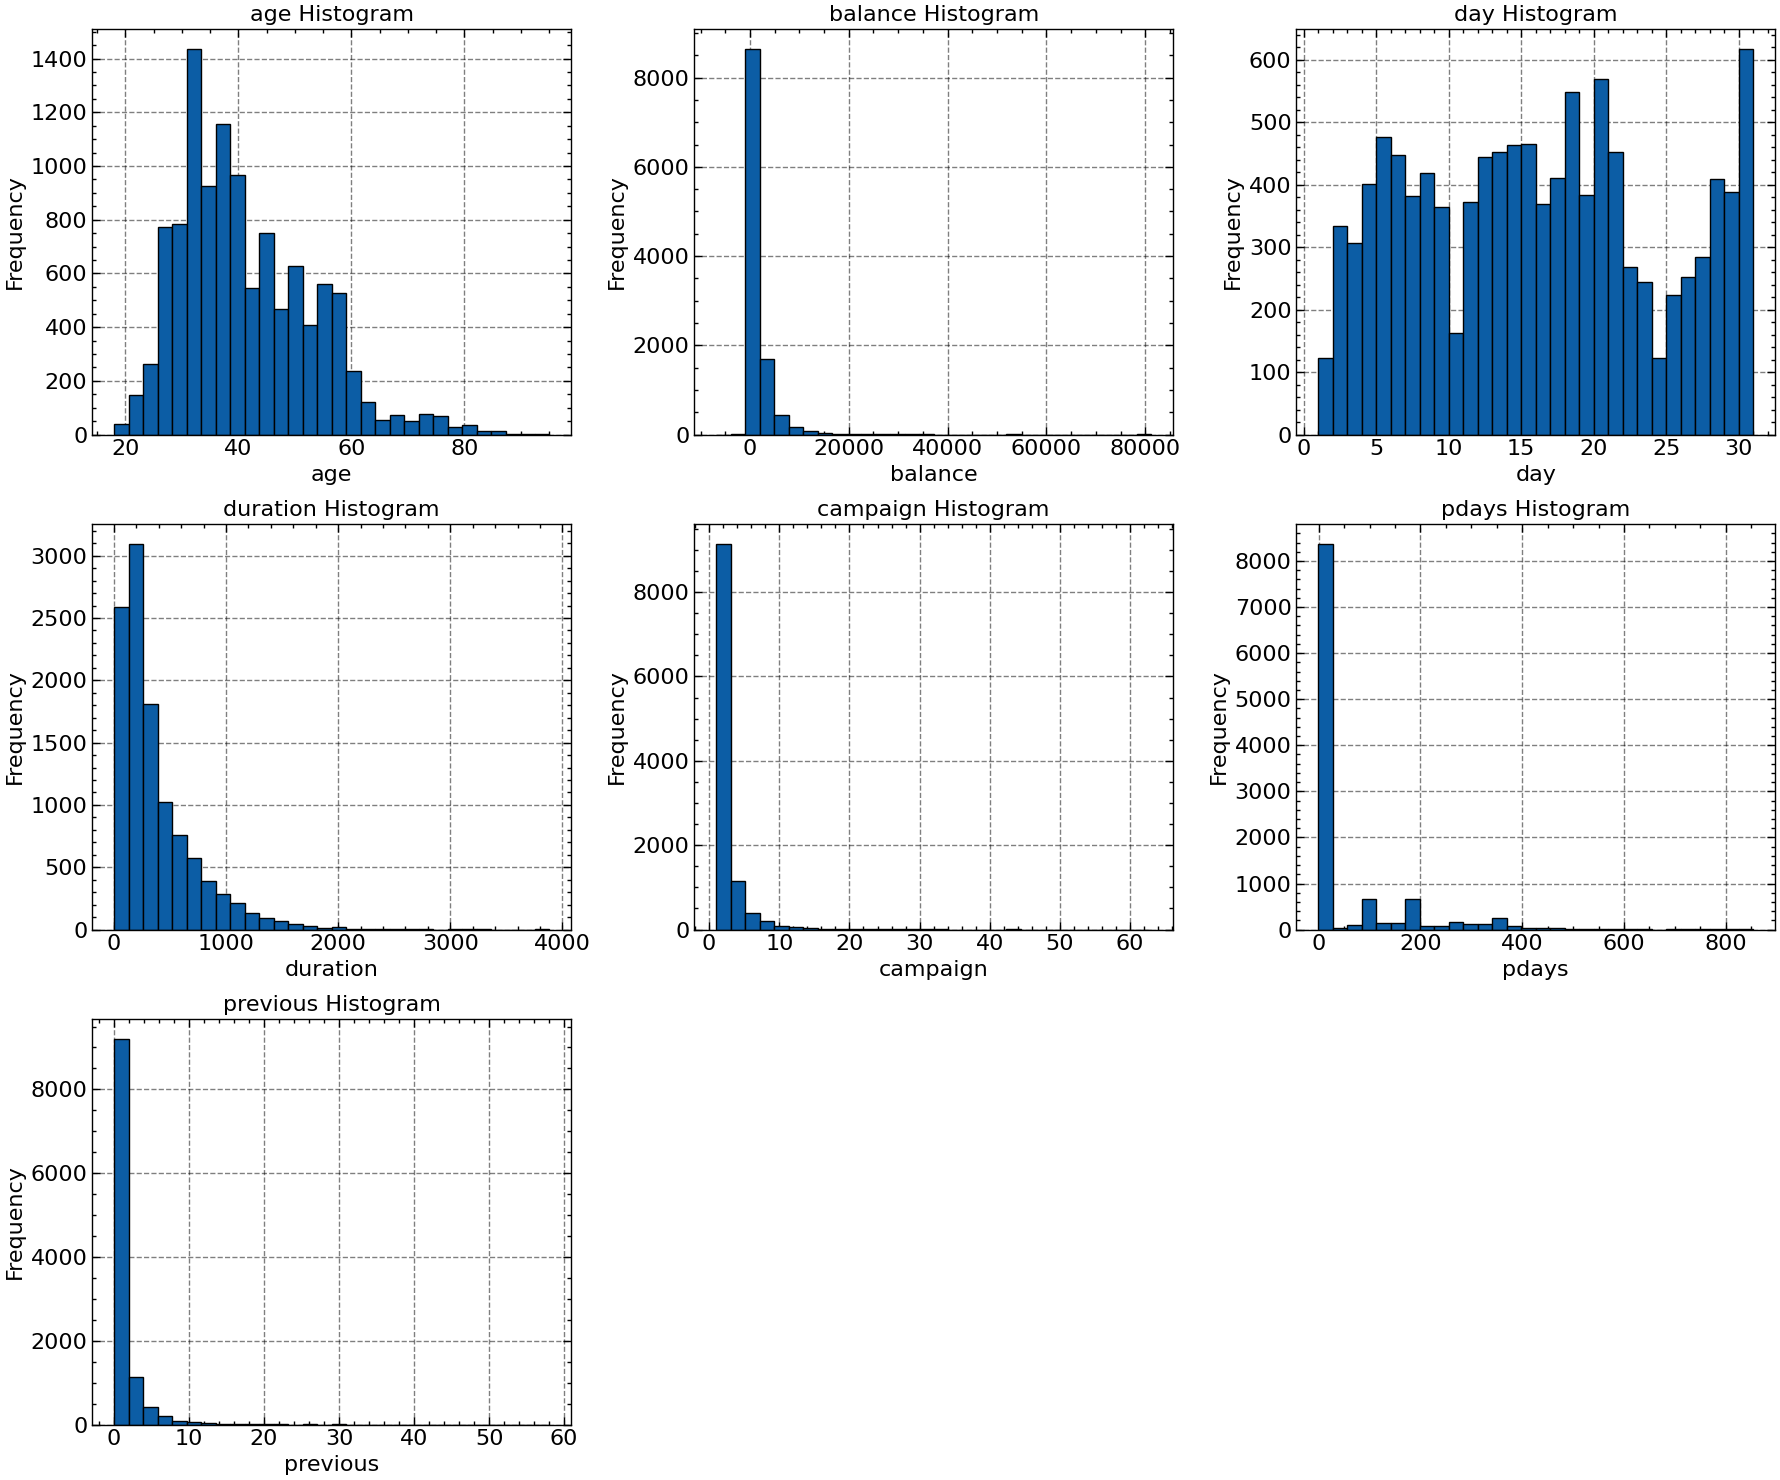

In [16]:
visualize_histograms(df)

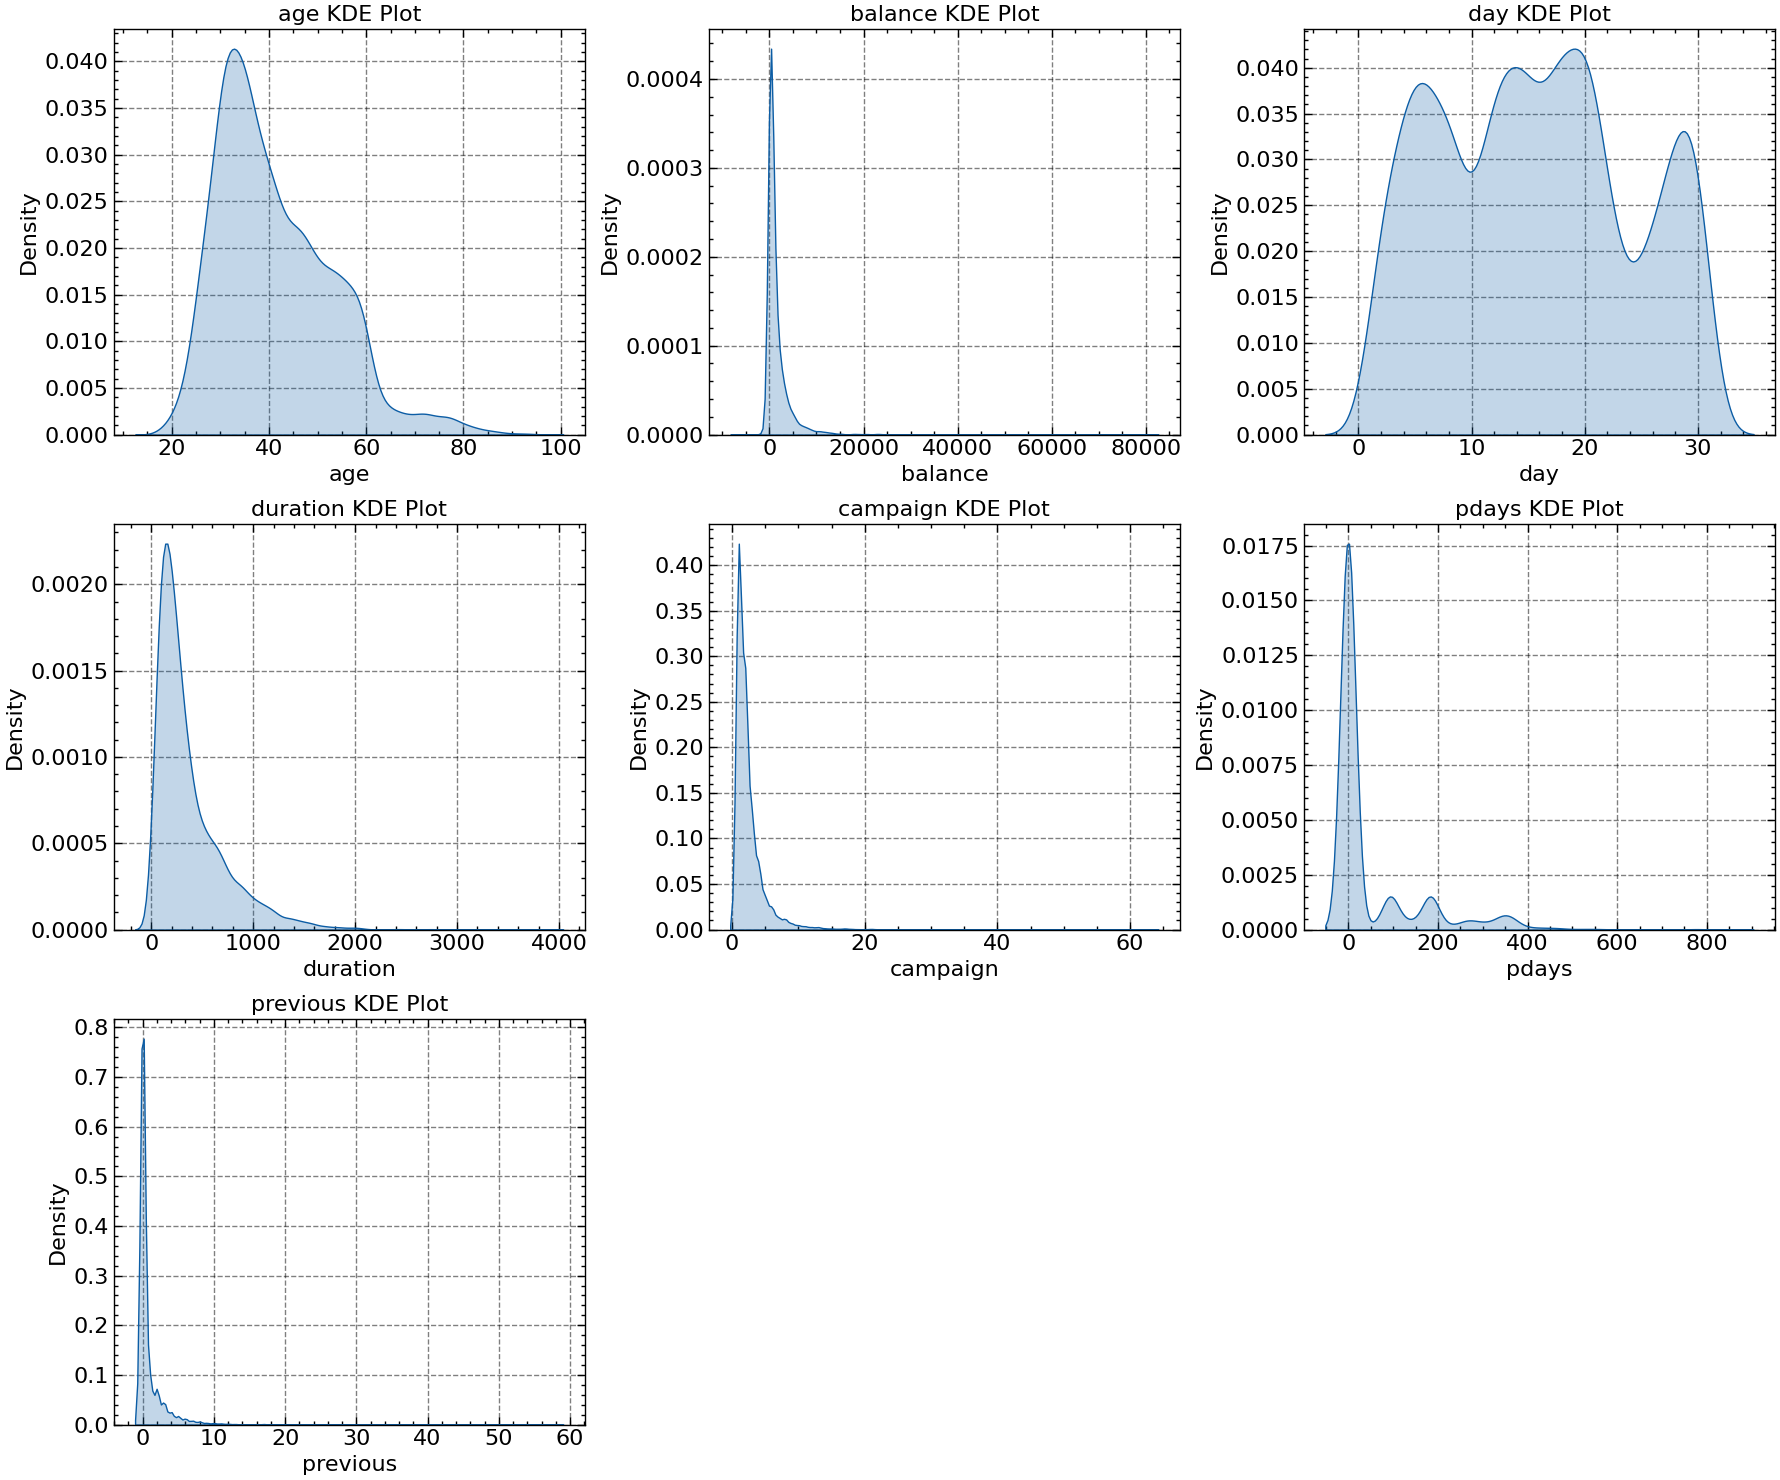

In [17]:
visualize_kde(df)

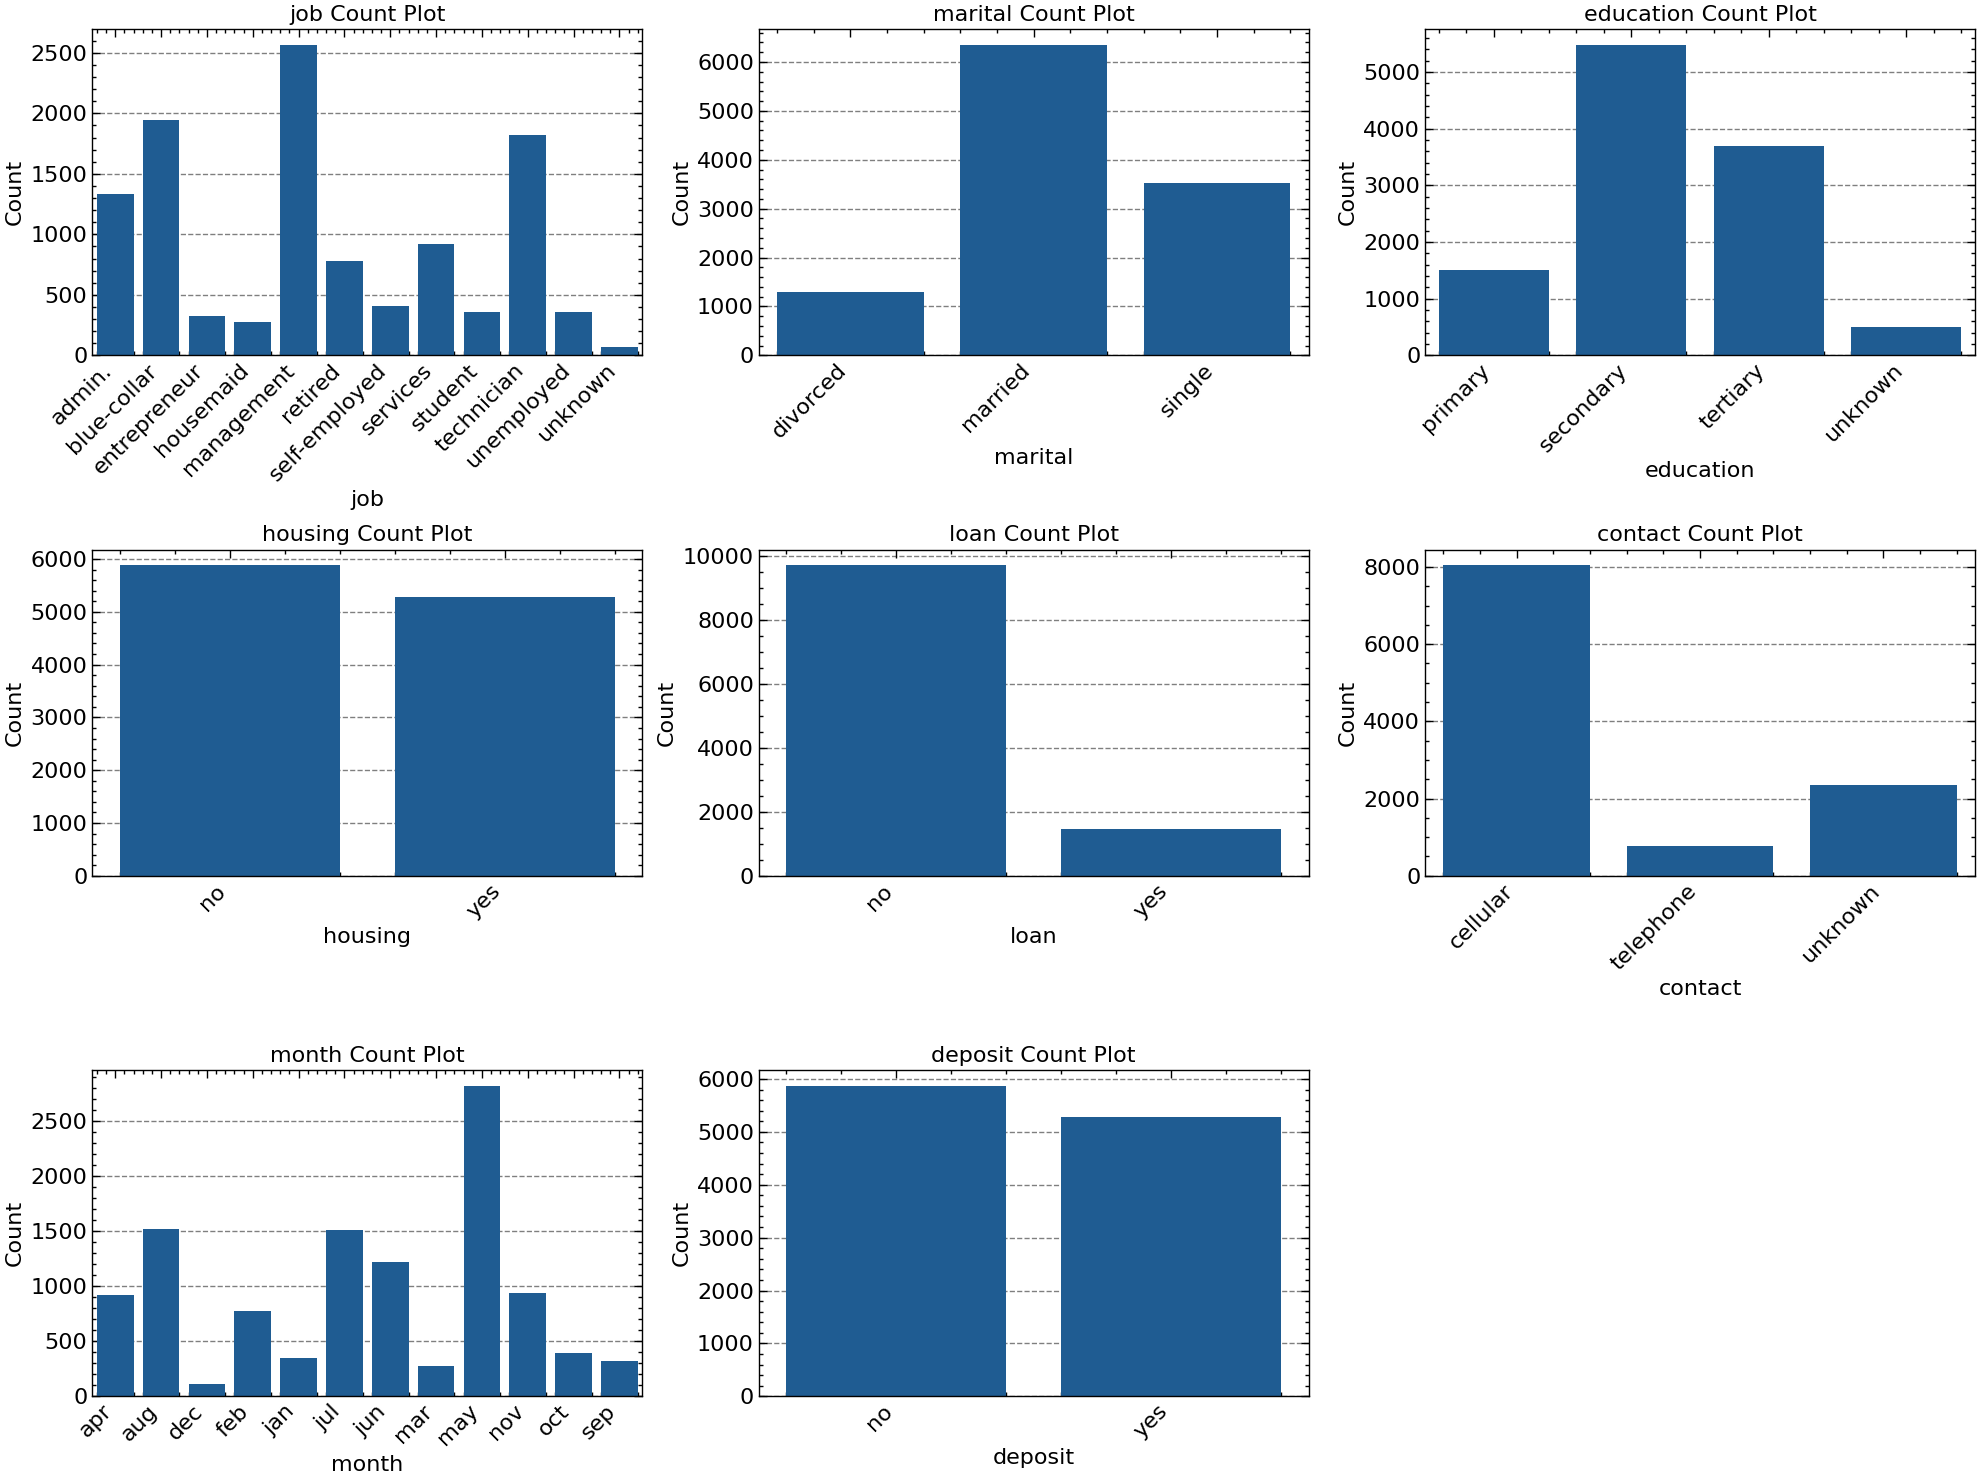

In [18]:
visualize_categorical(df)

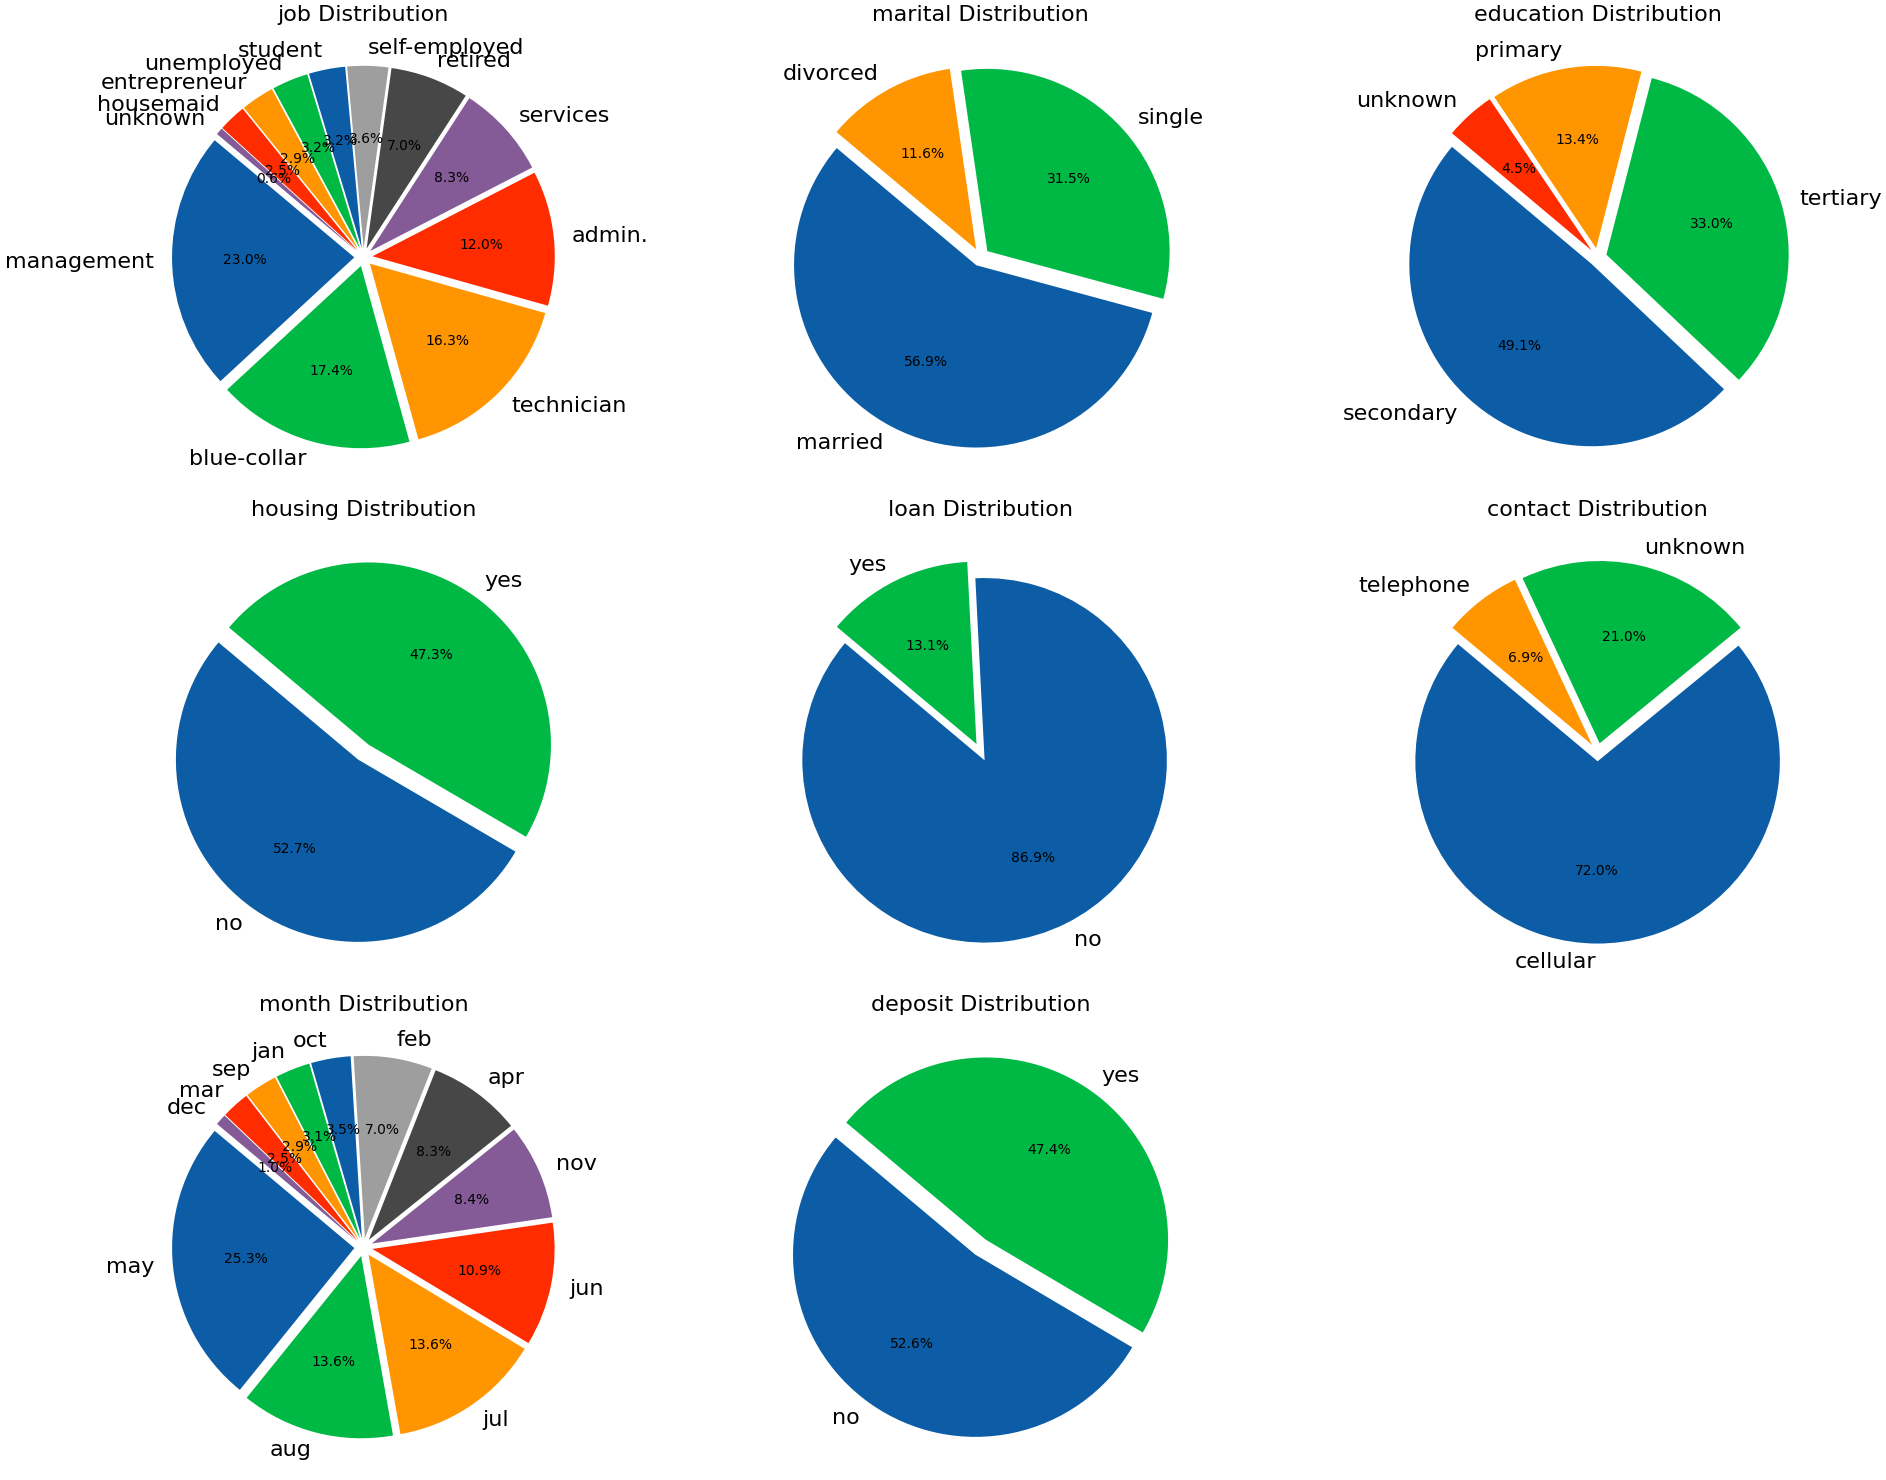

In [19]:
visualize_categorical_pie(df)

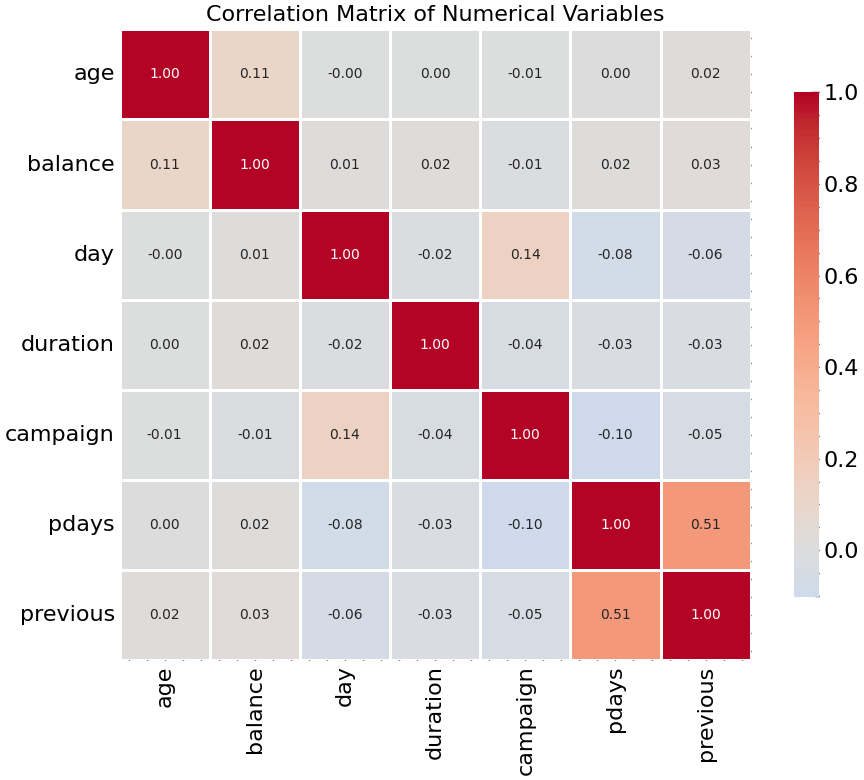

In [20]:
numerical_df = df.select_dtypes("number")
corr = numerical_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

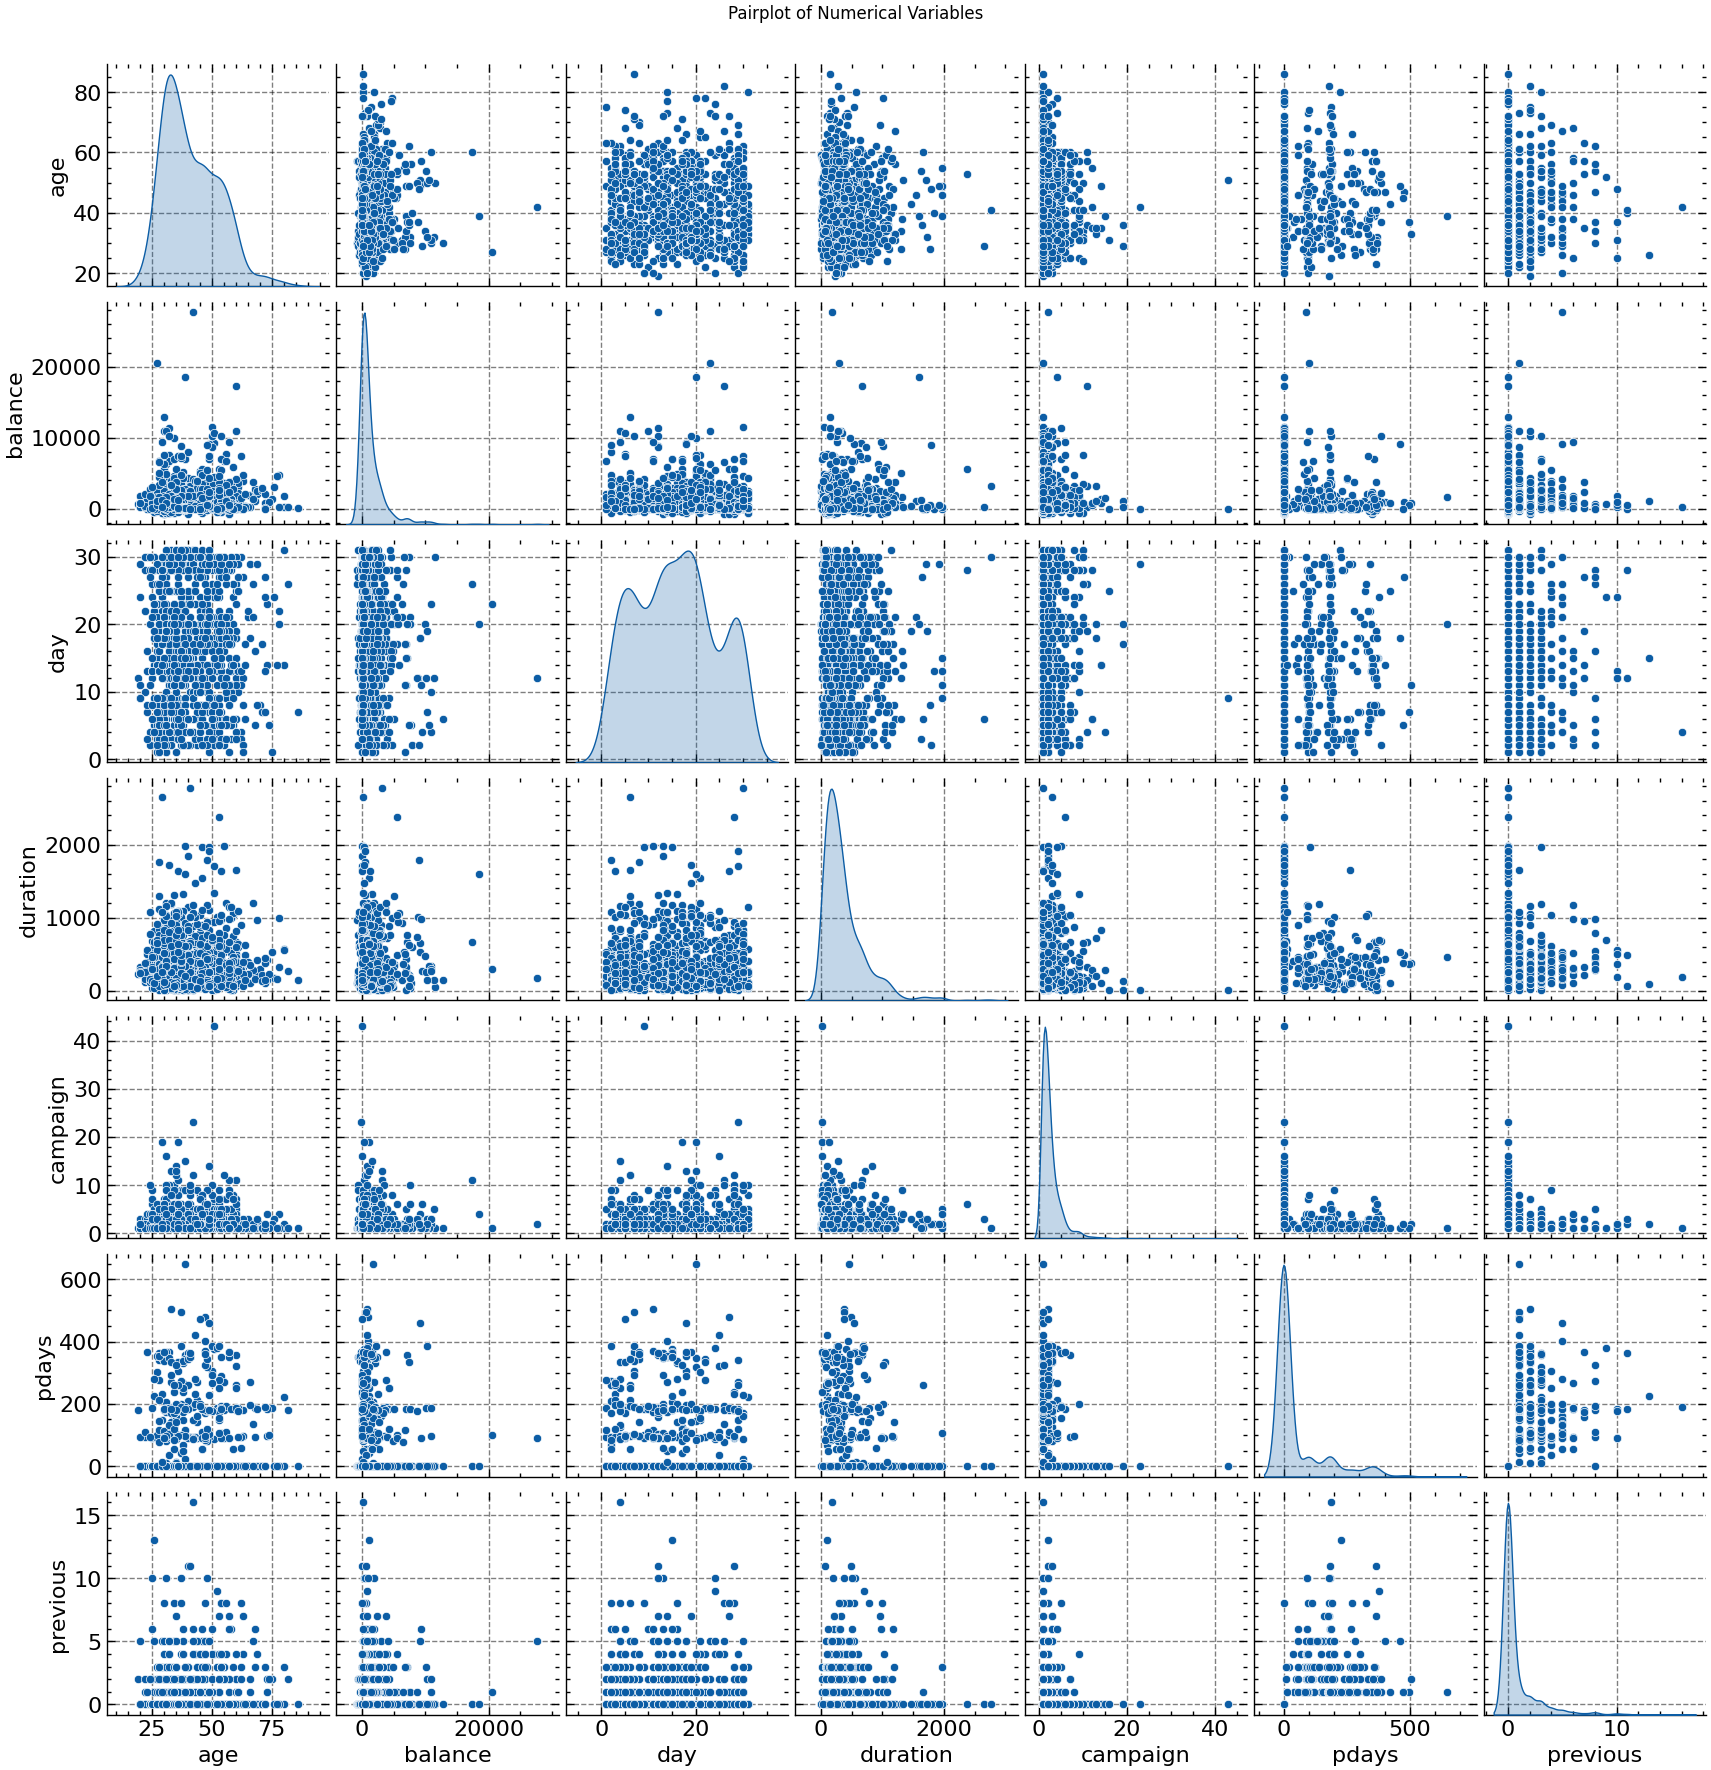

In [21]:
if len(df) > 1000:
    sample_df = df.sample(1000)
else:
    sample_df = df

sns.pairplot(sample_df.select_dtypes("number"), diag_kind="kde")
plt.suptitle("Pairplot of Numerical Variables", y=1.02)
plt.show()

## Target Variable Analysis (if applicable)


In [22]:
potential_targets = [col for col in df.columns if col.lower() in ['y', 'deposit', 'subscribed', 'target', 'outcome']]

if potential_targets:
    target_col = potential_targets[0]
    print(f"Target variable found: {target_col}")
    print(f"\nTarget distribution:")
    print(df[target_col].value_counts())
    print(f"\nTarget distribution percentage:")
    print(df[target_col].value_counts(normalize=True) * 100)
else:
    print("No obvious target variable found. Displaying all column names:")
    print(df.columns.tolist())

Target variable found: deposit

Target distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Target distribution percentage:
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


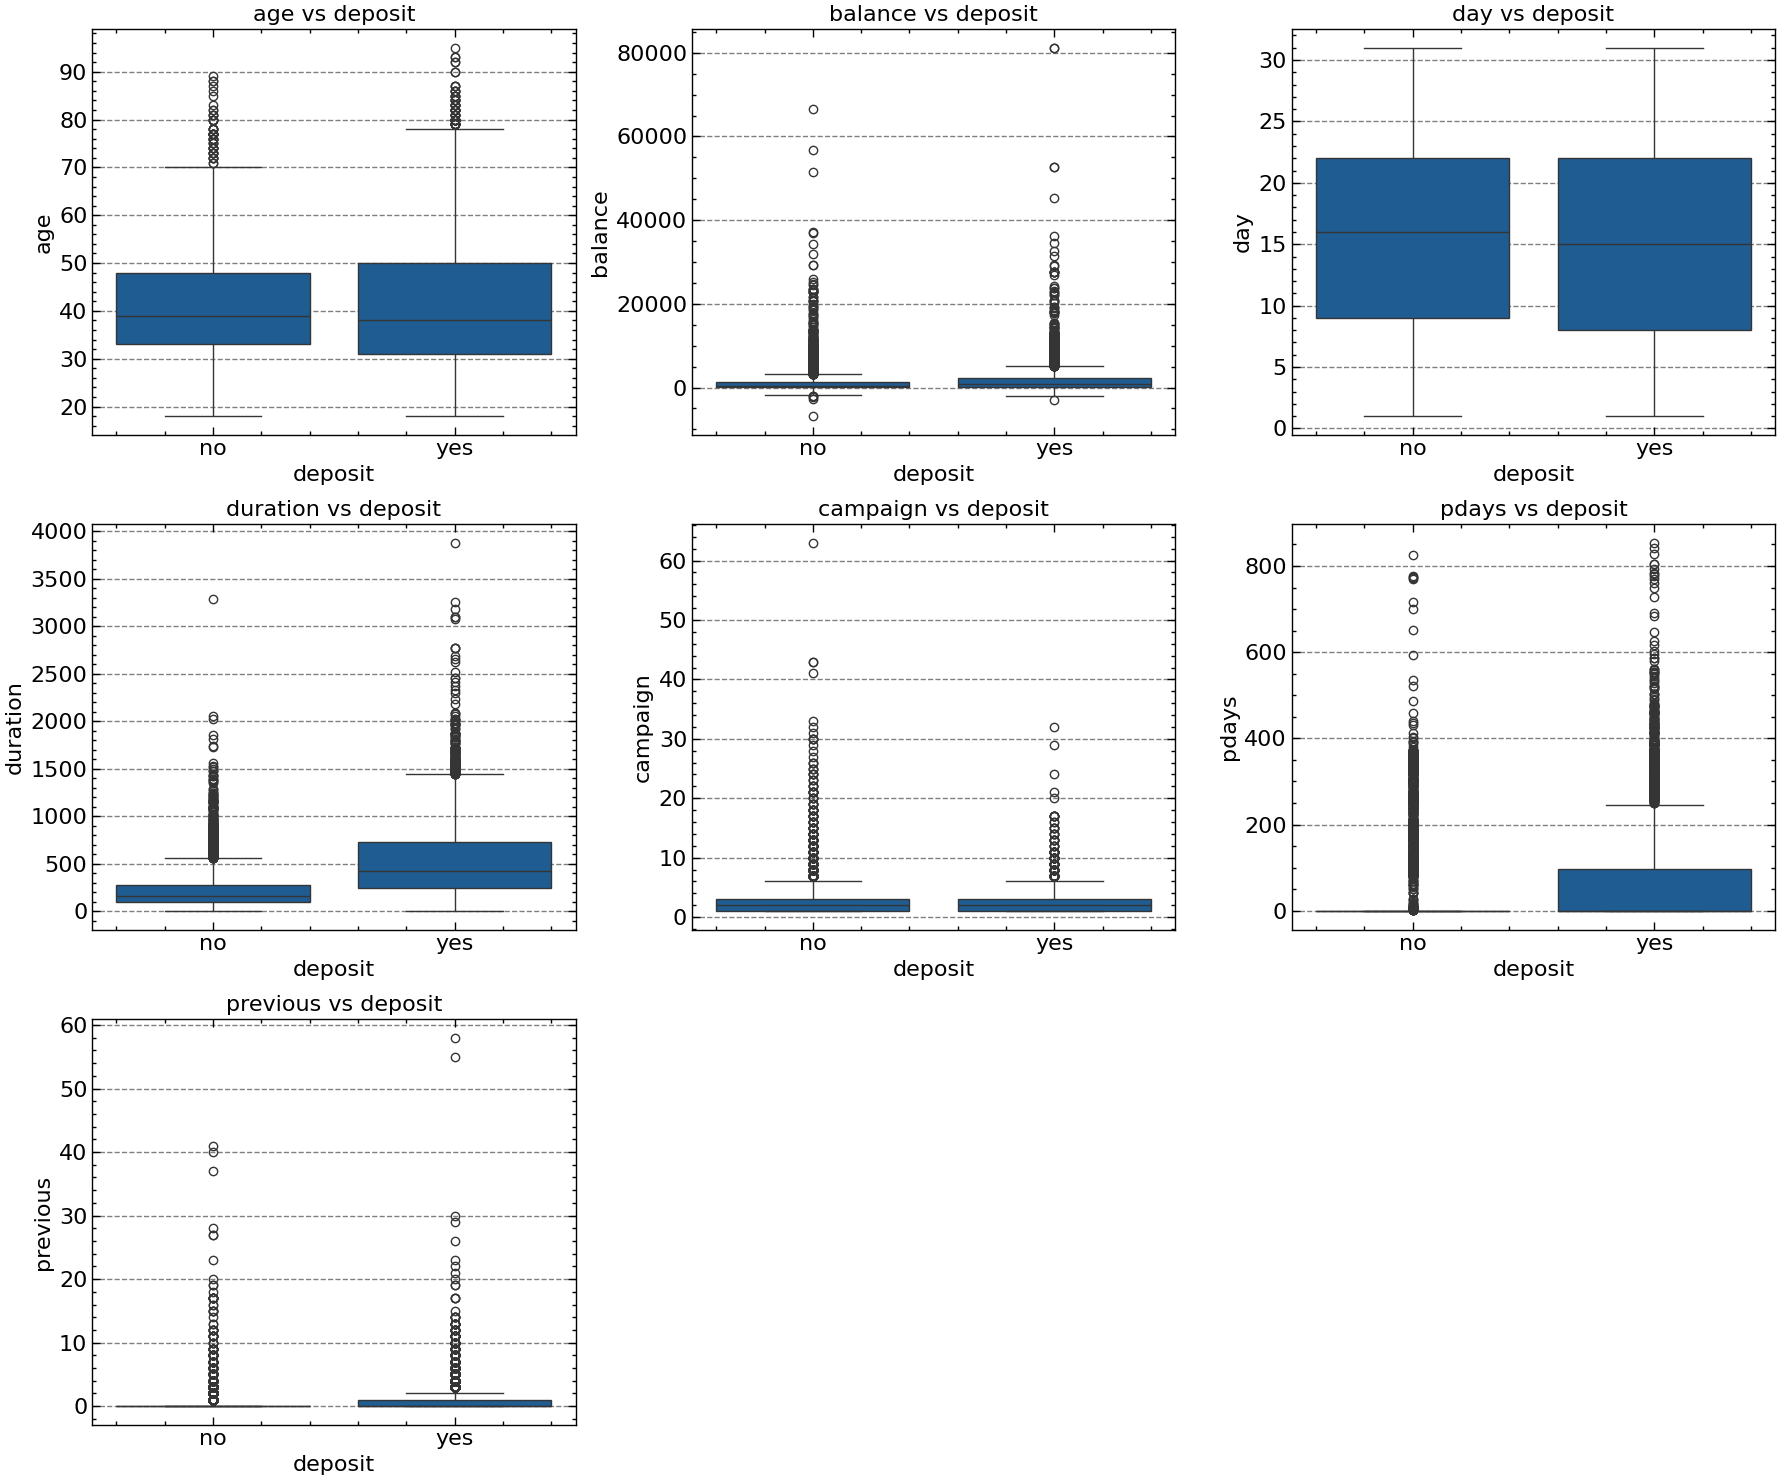

In [23]:
if potential_targets:
    target_col = potential_targets[0]
    
    num_cols_list = list(numerical_cols)
    if target_col in num_cols_list:
        num_cols_list.remove(target_col)
    
    if num_cols_list:
        num_plots = len(num_cols_list)
        rows = (num_plots // 3) + (1 if num_plots % 3 != 0 else 0)
        
        plt.figure(figsize=(18, 5 * rows))
        
        for i, col in enumerate(num_cols_list):
            plt.subplot(rows, 3, i+1)
            if df[target_col].dtype == 'category':
                sns.boxplot(data=df, x=target_col, y=col)
            else:
                sns.scatterplot(data=df, x=col, y=target_col, alpha=0.5)
            plt.title(f"{col} vs {target_col}")
        
        plt.tight_layout()
        plt.show()

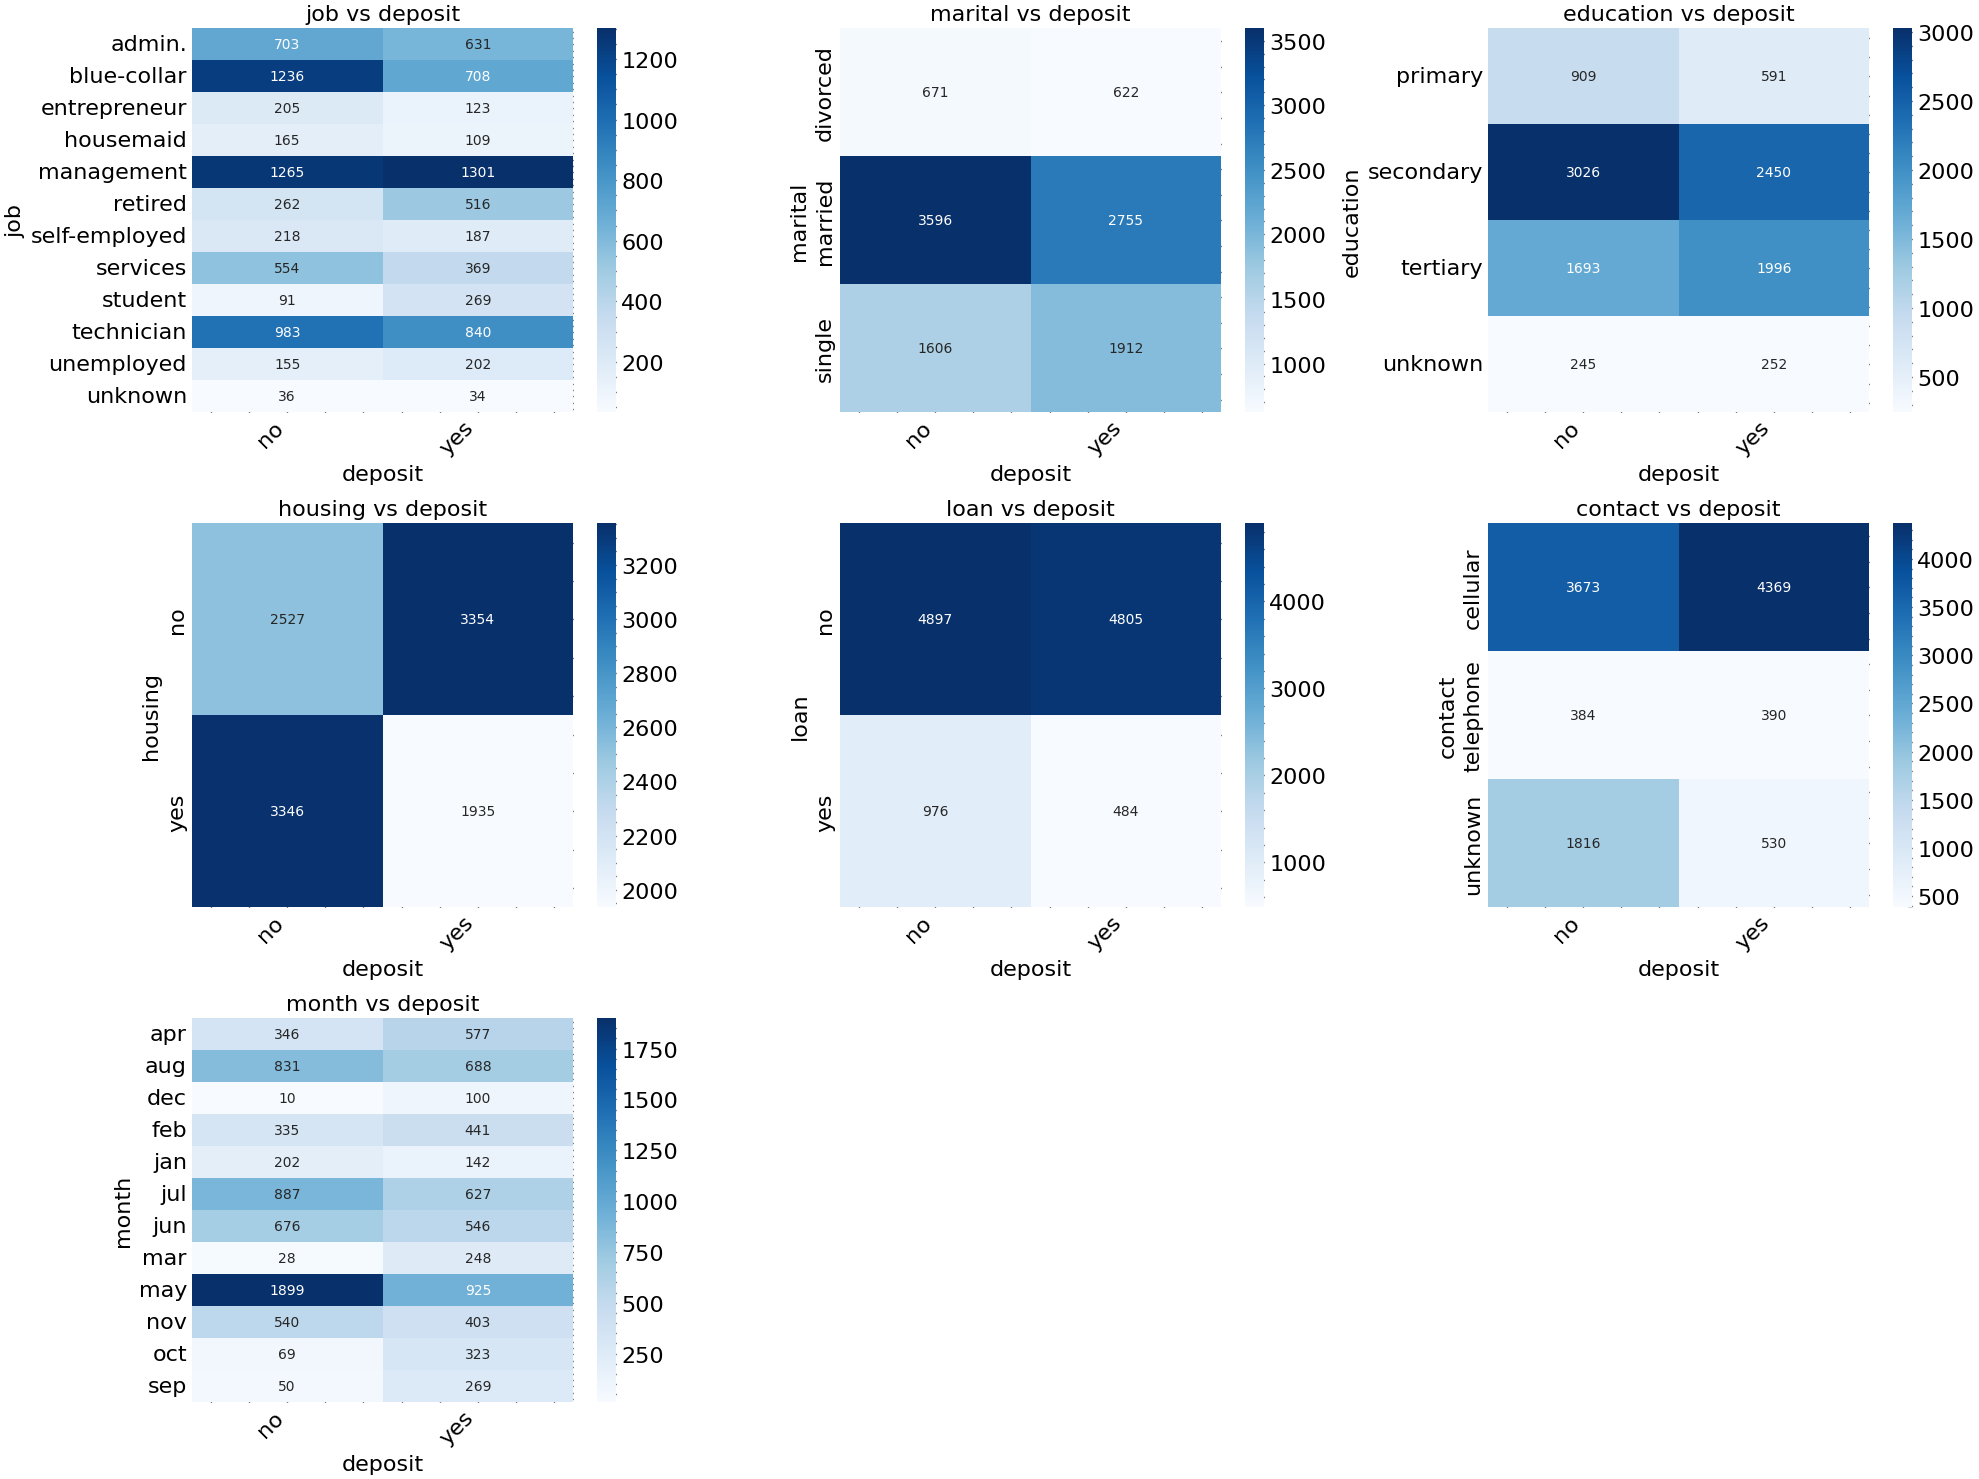

In [24]:
if potential_targets:
    target_col = potential_targets[0]
    cat_cols = df.select_dtypes("category").columns
    if target_col in cat_cols:
        cat_cols = [col for col in cat_cols if col != target_col]
    
    if len(cat_cols) > 0:
        num_plots = len(cat_cols)
        rows = (num_plots // 3) + (1 if num_plots % 3 != 0 else 0)
        
        plt.figure(figsize=(20, 5 * rows))
        
        for i, col in enumerate(cat_cols):
            plt.subplot(rows, 3, i+1)
            if df[target_col].dtype == 'category':
                crosstab = pd.crosstab(df[col], df[target_col])
                sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
            else:
                sns.barplot(data=df, x=col, y=target_col)
            plt.title(f"{col} vs {target_col}")
            plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()

## Data Preprocessing for Modeling (if target exists)


In [25]:
if potential_targets:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler, StandardScaler
    from category_encoders import OneHotEncoder, OrdinalEncoder
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    
    target_col = potential_targets[0]
    
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    if y.dtype == 'category':
        y = y.cat.codes
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"\nTarget distribution:")
    print(pd.Series(y).value_counts())


Features shape: (11162, 14)
Target shape: (11162,)

Target distribution:
0    5873
1    5289
Name: count, dtype: int64


In [26]:
if potential_targets:
    numerical_cols_features = X.select_dtypes("number").columns
    
    if len(numerical_cols_features) > 0:
        scaler = MinMaxScaler()
        X_scaled = X.copy()
        X_scaled[numerical_cols_features] = scaler.fit_transform(X[numerical_cols_features])
        X = X_scaled
        print("Numerical features scaled using MinMaxScaler")


Numerical features scaled using MinMaxScaler


In [27]:
if potential_targets:
    categorical_cols = X.select_dtypes("category").columns
    
    if len(categorical_cols) > 0:
        encoder = OneHotEncoder(cols=list(categorical_cols), drop_invariant=True, use_cat_names=True)
        X = encoder.fit_transform(X)
        print(f"Categorical features encoded. New shape: {X.shape}")
        print(f"\nEncoded feature names (first 10): {list(X.columns[:10])}")


Categorical features encoded. New shape: (11162, 45)

Encoded feature names (first 10): ['age', 'job_admin.', 'job_technician', 'job_services', 'job_management', 'job_retired', 'job_blue-collar', 'job_unemployed', 'job_entrepreneur', 'job_housemaid']


In [28]:
if potential_targets:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    print(f"Training set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")
    print(f"\nTraining target distribution:")
    print(pd.Series(y_train).value_counts())
    print(f"\nTest target distribution:")
    print(pd.Series(y_test).value_counts())


Training set shape: (8929, 45)
Test set shape: (2233, 45)

Training target distribution:
0    4698
1    4231
Name: count, dtype: int64

Test target distribution:
0    1175
1    1058
Name: count, dtype: int64


## Model Training and Evaluation


Logistic Regression Results:
Accuracy: 0.8213

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1175
           1       0.82      0.79      0.81      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



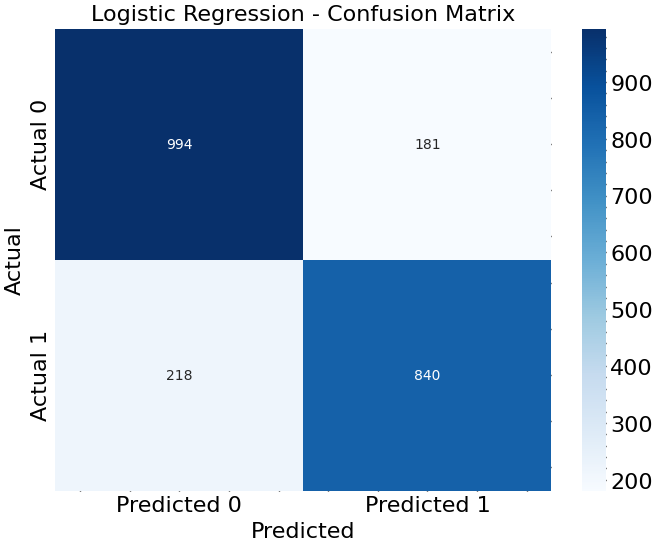

In [29]:
if potential_targets:
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train, y_train)
    
    y_pred_lr = lr_model.predict(X_test)
    
    print("Logistic Regression Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_lr))
    
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred_lr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title("Logistic Regression - Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


Random Forest Results:
Accuracy: 0.8500

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1175
           1       0.81      0.89      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233



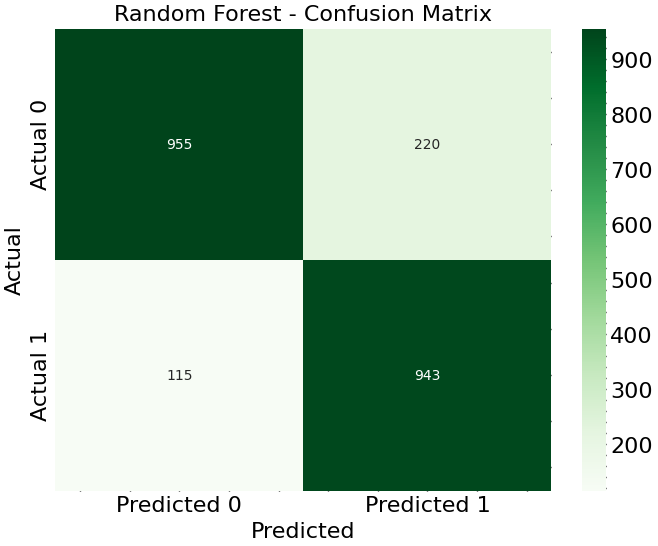

In [30]:
if potential_targets:
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf_model.fit(X_train, y_train)
    
    y_pred_rf = rf_model.predict(X_test)
    
    print("Random Forest Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_rf))
    
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred_rf)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title("Random Forest - Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


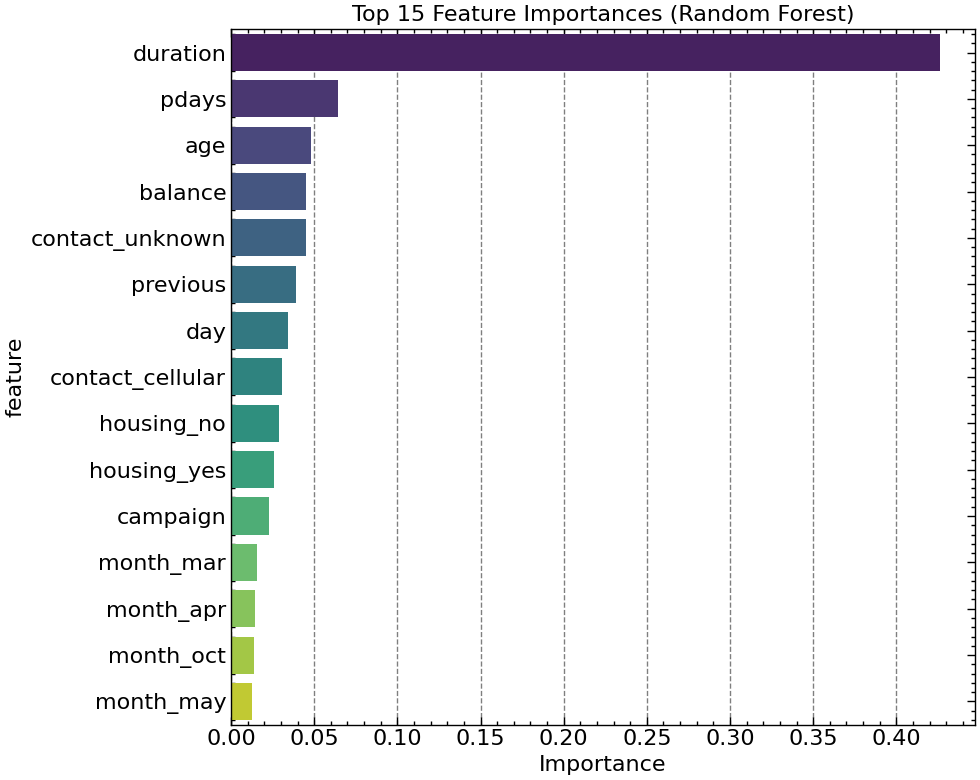


Top 10 Most Important Features:
             feature  importance
41          duration    0.426015
43             pdays    0.064426
0                age    0.047843
20           balance    0.045131
25   contact_unknown    0.044955
44          previous    0.039296
28               day    0.034129
26  contact_cellular    0.030660
22        housing_no    0.028899
21       housing_yes    0.025735


In [31]:
if potential_targets:
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
    plt.title("Top 15 Feature Importances (Random Forest)")
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))

## Summary and Conclusions


In [32]:
print("=" * 60)
print("DATA ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features: {len(df.columns)}")
print(f"Number of Numerical Features: {len(df.select_dtypes('number').columns)}")
print(f"Number of Categorical Features: {len(df.select_dtypes('category').columns)}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

try:
    if potential_targets:
        target_col = potential_targets[0]
        print(f"\nTarget Variable: {target_col}")
        print(f"Target Distribution:")
        print(df[target_col].value_counts())
        try:
            print(f"\nModel Performance:")
            print(f"  - Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
            print(f"  - Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
        except NameError:
            pass
except NameError:
    pass

print("\n" + "=" * 60)

DATA ANALYSIS SUMMARY

Dataset Shape: (11162, 15)
Number of Features: 15
Number of Numerical Features: 7
Number of Categorical Features: 8
Missing Values: 0
Duplicate Rows: 0

Target Variable: deposit
Target Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Model Performance:
  - Logistic Regression Accuracy: 0.8213
  - Random Forest Accuracy: 0.8500

